In [ ]:
# Urdu Poetry Generation using Neural Networks

This project explores sequence modeling techniques to generate Urdu poetry using deep learning models.

The goal is to learn patterns in poetic text and generate coherent and stylistically consistent verses.

In [1]:
# ============================================================================
# CELL 2: Import Libraries & Set Up
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Set seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create directories (Kaggle-style)
os.makedirs('/kaggle/working/output', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)


Using device: cuda


In [3]:
# ============================================================================
# CELL 3: Load Dataset
# ============================================================================
print("Loading Urdu Poetry Dataset...")

dataset = load_dataset("ReySajju742/Urdu-Poetry-Dataset", split="train")
print(f"Dataset loaded! Total poems: {len(dataset)}")


Loading Urdu Poetry Dataset...


README.md: 0.00B [00:00, ?B/s]

output_ur.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1323 [00:00<?, ? examples/s]

Dataset loaded! Total poems: 1323


In [11]:
print("Columns:", dataset.column_names)
print("\nFirst row:")
print(dataset[0])


Columns: ['title', 'content']

First row:
{'title': 'be-thikaane-hai-dil-e-gam-ghiin-thikaane-kii-kaho-firaq-gorakhpuri-ghazals', 'content': '\nبے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو \nشام ہجراں دوستو کچھ اس کے آنے کی کہو \nہاں نہ پوچھ اک گرفتار قفس کی زندگی \nہم صفیران چمن کچھ آشیانے کی کہو \nاڑ گیا ہے منزل دشوار میں غم کا سمند \nگیسوئے پر پیچ و خم کے تازیانے کی کہو \nبات بنتی اور باتوں سے نظر آتی نہیں \nاس نگاہ ناز کی باتیں بنانے کی کہو \nداستاں وہ تھی جسے دل بجھتے بجھتے کہہ گیا \nشمع بزم زندگی کے جھلملانے کی کہو \nکچھ دل مرحوم کی باتیں کرو اے اہل علم \nجس سے ویرانے تھے آباد اس دوانے کی کہو \nداستان زندگی بھی کس قدر دلچسپ ہے \nجو ازل سے چھڑ گیا ہے اس فسانے کی کہو \nیہ فسون نیم شب یہ خواب\u200c\u200c ساماں خامشی \nسامری فن آنکھ کے جادو جگانے کی کہو \nکوئی کیا کھائے گا یوں سچی قسم جھوٹی قسم \nاس نگاہ ناز کی سوگندھ کھانے کی کہو \nشام ہی سے گوش بر آواز ہے بزم سخن \nکچھ فراقؔ اپنی سناؤ کچھ زمانے کی کہو '}


In [16]:
print("\n" + "="*80)
print("DATASET EXPLORATION")
print("="*80)

print(f"\nSample poem:")

sample = dataset[0]
title = sample['title']
content = sample['content'] or ""   # handle None just in case

print(f"Title: {title}")
print(f"Content:\n{content[:300]}...")

def safe_content(poem):
    c = poem['content']
    return c if c is not None else ""

# Basic stats using safe_content
poem_texts  = [safe_content(poem) for poem in dataset]
poem_lengths = [len(text) for text in poem_texts]
word_counts  = [len(text.split()) for text in poem_texts]

print(f"\nStatistics:")
print(f"Avg characters: {np.mean(poem_lengths):.2f}")
print(f"Avg words: {np.mean(word_counts):.2f}")
print(f"Min words: {min(word_counts)}")
print(f"Max words: {max(word_counts)}")



DATASET EXPLORATION

Sample poem:
Title: be-thikaane-hai-dil-e-gam-ghiin-thikaane-kii-kaho-firaq-gorakhpuri-ghazals
Content:

بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو 
شام ہجراں دوستو کچھ اس کے آنے کی کہو 
ہاں نہ پوچھ اک گرفتار قفس کی زندگی 
ہم صفیران چمن کچھ آشیانے کی کہو 
اڑ گیا ہے منزل دشوار میں غم کا سمند 
گیسوئے پر پیچ و خم کے تازیانے کی کہو 
بات بنتی اور باتوں سے نظر آتی نہیں 
اس نگاہ ناز کی باتیں بنانے کی کہو 
داستاں وہ...

Statistics:
Avg characters: 560.88
Avg words: 130.93
Min words: 0
Max words: 511


In [18]:
# ============================================================================
# CELL 5: Extract Lines
# ============================================================================

print("\nExtracting lines...")

all_lines = []
for poem in dataset:
    content = poem['content']
    if not content:  # skip None or empty strings
        continue
    # split by newline, remove empty lines
    lines = [line.strip() for line in content.split('\n') if line.strip()]
    all_lines.extend(lines)

print(f"Total lines: {len(all_lines)}")

print("\nSample lines:")
for i in range(5):
    print(f"{i+1}. {all_lines[i]}")



Extracting lines...
Total lines: 21068

Sample lines:
1. بے ٹھکانے ہے دل غمگیں ٹھکانے کی کہو
2. شام ہجراں دوستو کچھ اس کے آنے کی کہو
3. ہاں نہ پوچھ اک گرفتار قفس کی زندگی
4. ہم صفیران چمن کچھ آشیانے کی کہو
5. اڑ گیا ہے منزل دشوار میں غم کا سمند


In [20]:
# ============================================================================
# CELL 6: Create Vocabulary
# ============================================================================

print("\nCreating vocabulary...")

# Merge all lines into one text block
all_text = " ".join(all_lines)
words = all_text.split()

from collections import Counter
word_counts = Counter(words)

print(f"Total words: {len(words)}")
print(f"Unique words: {len(word_counts)}")

MAX_VOCAB_SIZE = 10000

# Reserve 0=<PAD>, 1=<UNK>
word2idx = {"<PAD>": 0, "<UNK>": 1}

# Most common words fill the vocab
most_common = word_counts.most_common(MAX_VOCAB_SIZE - 2)
for idx, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = idx

idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)

print(f"Final vocabulary size: {vocab_size}")



Creating vocabulary...
Total words: 173214
Unique words: 10507
Final vocabulary size: 10000


In [40]:
# ============================================================================
# NEW CELL 7: Create Sequences with REAL targets (no PAD as y)
# ============================================================================

print("\nCreating sequences (fixed input length, real next-word targets)...")

SEQUENCE_LENGTH = 15   # context length

input_sequences = []
targets = []

for line in all_lines:
    words = line.split()
    if len(words) < 2:
        continue
    token_list = [word2idx.get(w, word2idx["<UNK>"]) for w in words]

    # For each position i, predict word i given words [0..i-1]
    for i in range(1, len(token_list)):
        in_seq = token_list[:i]      # history
        target = token_list[i]       # next word

        input_sequences.append(in_seq)
        targets.append(target)

print(f"Total raw sequences: {len(input_sequences)}")

def pad_input(seq, max_len, pad_value=0):
    if len(seq) < max_len:
        # left-pad so recent words are at the end
        return [pad_value] * (max_len - len(seq)) + seq
    else:
        # keep the last max_len tokens
        return seq[-max_len:]

padded_inputs = [pad_input(seq, SEQUENCE_LENGTH) for seq in input_sequences]

X = np.array(padded_inputs)
y = np.array(targets)

print("X shape:", X.shape)   # (num_sequences, 15)
print("y shape:", y.shape)   # (num_sequences,)
print("Example X[0]:", X[0])
print("Example y[0]:", y[0])



Creating sequences (fixed input length, real next-word targets)...
Total raw sequences: 152146
X shape: (152146, 15)
y shape: (152146,)
Example X[0]: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 33]
Example y[0]: 1654


In [42]:
# ============================================================================
# CELL 8: Train/Val/Test Split
# ============================================================================

total = len(X)
indices = np.arange(total)
np.random.shuffle(indices)

train_size = int(0.8 * total)
val_size = int(0.1 * total)

train_idx = indices[:train_size]
val_idx   = indices[train_size:train_size + val_size]
test_idx  = indices[train_size + val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")


Train size: 121716
Val size: 15214
Test size: 15216


In [44]:
# ============================================================================
# CELL 9: Dataset + DataLoader
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader

class UrduPoetryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = UrduPoetryDataset(X_train, y_train)
val_dataset   = UrduPoetryDataset(X_val,   y_val)
test_dataset  = UrduPoetryDataset(X_test,  y_test)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders ready!")


Dataloaders ready!


In [46]:
# ============================================================================
# CELL 10: Define Simple RNN Model
# ============================================================================

import torch.nn as nn
import torch.nn.functional as F

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=512, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        embedded = self.embedding(x)             # (batch, seq_len, emb)
        output, hidden = self.rnn(embedded, hidden)  # output: (batch, seq_len, hidden)
        last_step = output[:, -1, :]             # (batch, hidden)
        last_step = self.dropout(last_step)
        logits = self.fc(last_step)              # (batch, vocab_size)
        return logits, hidden

print("SimpleRNN defined.")


SimpleRNN defined.


In [48]:
# ============================================================================
# CELL 11: Define LSTM Model
# ============================================================================

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=512, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)
        last_step = output[:, -1, :]
        last_step = self.dropout(last_step)
        logits = self.fc(last_step)
        return logits, hidden

print("LSTMModel defined.")


LSTMModel defined.


In [50]:
# ============================================================================
# CELL 12: Define Transformer Model
# ============================================================================

import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # even
        pe[:, 1::2] = torch.cos(position * div_term)  # odd
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=False  # Transformer expects (seq_len, batch, d_model)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        # x: (batch, seq_len)
        padding_mask = (x == 0)  # True where PAD
        embedded = self.embedding(x) * math.sqrt(self.d_model)  # (batch, seq_len, d_model)
        embedded = self.pos_encoder(embedded)
        embedded = self.dropout(embedded)
        
        # Transformer: (seq_len, batch, d_model)
        embedded = embedded.transpose(0, 1)
        output = self.transformer_encoder(embedded, src_key_padding_mask=padding_mask)  # (seq_len, batch, d_model)
        
        last_step = output[-1, :, :]   # (batch, d_model)
        logits = self.fc(last_step)    # (batch, vocab_size)
        return logits

print("TransformerModel defined.")


TransformerModel defined.


In [52]:
# ============================================================================
# CELL 13: Training & Evaluation Functions
# ============================================================================

# Make sure device is defined (in case you didn't earlier)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        if isinstance(model, (SimpleRNN, LSTMModel)):
            logits, _ = model(batch_x)
        else:
            logits = model(batch_x)
        
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        _, preds = torch.max(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    perplexity = math.exp(avg_loss)
    return avg_loss, accuracy, perplexity


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            if isinstance(model, (SimpleRNN, LSTMModel)):
                logits, _ = model(batch_x)
            else:
                logits = model(batch_x)
            
            loss = criterion(logits, batch_y)
            total_loss += loss.item()
            
            _, preds = torch.max(logits, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    perplexity = math.exp(avg_loss)
    return avg_loss, accuracy, perplexity


def train_model(model, model_name, opt_name,
                train_loader, val_loader,
                criterion, optimizer,
                num_epochs=20, patience=5):
    print(f"\nTraining {model_name} with {opt_name}")
    print("=" * 80)
    
    history = {
        "train_loss": [], "train_acc": [], "train_ppl": [],
        "val_loss": [], "val_acc": [], "val_ppl": []
    }
    
    best_val_loss = float("inf")
    patience_counter = 0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        train_loss, train_acc, train_ppl = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_ppl = evaluate(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_ppl"].append(train_ppl)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_ppl"].append(val_ppl)
        
        print(
            f"Epoch {epoch+1:02d}/{num_epochs:02d} | "
            f"Train Loss: {train_loss:.4f}, PPL: {train_ppl:.2f}, Acc: {train_acc:.3f} || "
            f"Val Loss: {val_loss:.4f}, PPL: {val_ppl:.2f}, Acc: {val_acc:.3f}"
        )
        
        # Early stopping on val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best weights
            os.makedirs("models", exist_ok=True)
            torch.save(model.state_dict(), f"models/{model_name}_{opt_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    total_time = time.time() - start_time
    print(f"Training time: {total_time/60:.2f} minutes")
    print("=" * 80)
    
    return history, total_time


Using device: cuda


In [54]:
# ============================================================================
# CELL 14: Train All Model–Optimizer Combinations
# ============================================================================

models_config = {
    "RNN": lambda: SimpleRNN(vocab_size),
    "LSTM": lambda: LSTMModel(vocab_size),
    "Transformer": lambda: TransformerModel(vocab_size),
}

def get_optimizer(model, opt_name):
    if opt_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=0.001)
    elif opt_name == "RMSprop":
        return torch.optim.RMSprop(model.parameters(), lr=0.001)
    elif opt_name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

optimizer_names = ["Adam", "RMSprop", "SGD"]

all_results = []
all_histories = {}

print("\nStarting training for all model–optimizer combinations...\n")

for model_name, model_fn in models_config.items():
    for opt_name in optimizer_names:
        print(f"\n=== {model_name} + {opt_name} ===")
        model = model_fn().to(device)
        optimizer = get_optimizer(model, opt_name)
        
        history, train_time = train_model(
            model=model,
            model_name=model_name,
            opt_name=opt_name,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=20,
            patience=5,
        )
        
        # Load best weights & evaluate on test set
        model.load_state_dict(torch.load(f"models/{model_name}_{opt_name}_best.pth"))
        test_loss, test_acc, test_ppl = evaluate(model, test_loader, criterion, device)
        
        result = {
            "Model": model_name,
            "Optimizer": opt_name,
            "Best_Val_Perplexity": min(history["val_ppl"]),
            "Test_Loss": test_loss,
            "Test_Accuracy": test_acc,
            "Test_Perplexity": test_ppl,
            "Training_Time_Minutes": train_time / 60.0,
        }
        all_results.append(result)
        all_histories[f"{model_name}_{opt_name}"] = history
        
        print(
            f"TEST — {model_name} + {opt_name}: "
            f"Loss={test_loss:.4f}, PPL={test_ppl:.2f}, Acc={test_acc:.3f}, "
            f"Time={train_time/60.0:.2f} min"
        )

results_df = pd.DataFrame(all_results)
os.makedirs("output", exist_ok=True)
results_df.to_csv("output/all_results.csv", index=False)

print("\nAll combinations finished!")
print(results_df.to_string(index=False))



Starting training for all model–optimizer combinations...


=== RNN + Adam ===

Training RNN with Adam
Epoch 01/20 | Train Loss: 7.2326, PPL: 1383.86, Acc: 0.036 || Val Loss: 7.1005, PPL: 1212.59, Acc: 0.043
Epoch 02/20 | Train Loss: 7.1214, PPL: 1238.20, Acc: 0.037 || Val Loss: 7.1378, PPL: 1258.60, Acc: 0.037
Epoch 03/20 | Train Loss: 7.0958, PPL: 1206.85, Acc: 0.037 || Val Loss: 7.1163, PPL: 1231.92, Acc: 0.047
Epoch 04/20 | Train Loss: 7.0615, PPL: 1166.14, Acc: 0.040 || Val Loss: 7.1195, PPL: 1235.85, Acc: 0.044
Epoch 05/20 | Train Loss: 7.0139, PPL: 1111.98, Acc: 0.044 || Val Loss: 7.0632, PPL: 1168.14, Acc: 0.052
Epoch 06/20 | Train Loss: 6.9666, PPL: 1060.58, Acc: 0.052 || Val Loss: 7.0367, PPL: 1137.58, Acc: 0.055
Epoch 07/20 | Train Loss: 6.8885, PPL: 980.90, Acc: 0.058 || Val Loss: 7.0266, PPL: 1126.23, Acc: 0.066
Epoch 08/20 | Train Loss: 6.7895, PPL: 888.50, Acc: 0.065 || Val Loss: 6.9332, PPL: 1025.81, Acc: 0.064
Epoch 09/20 | Train Loss: 6.6533, PPL: 775.33, Acc: 0.071 

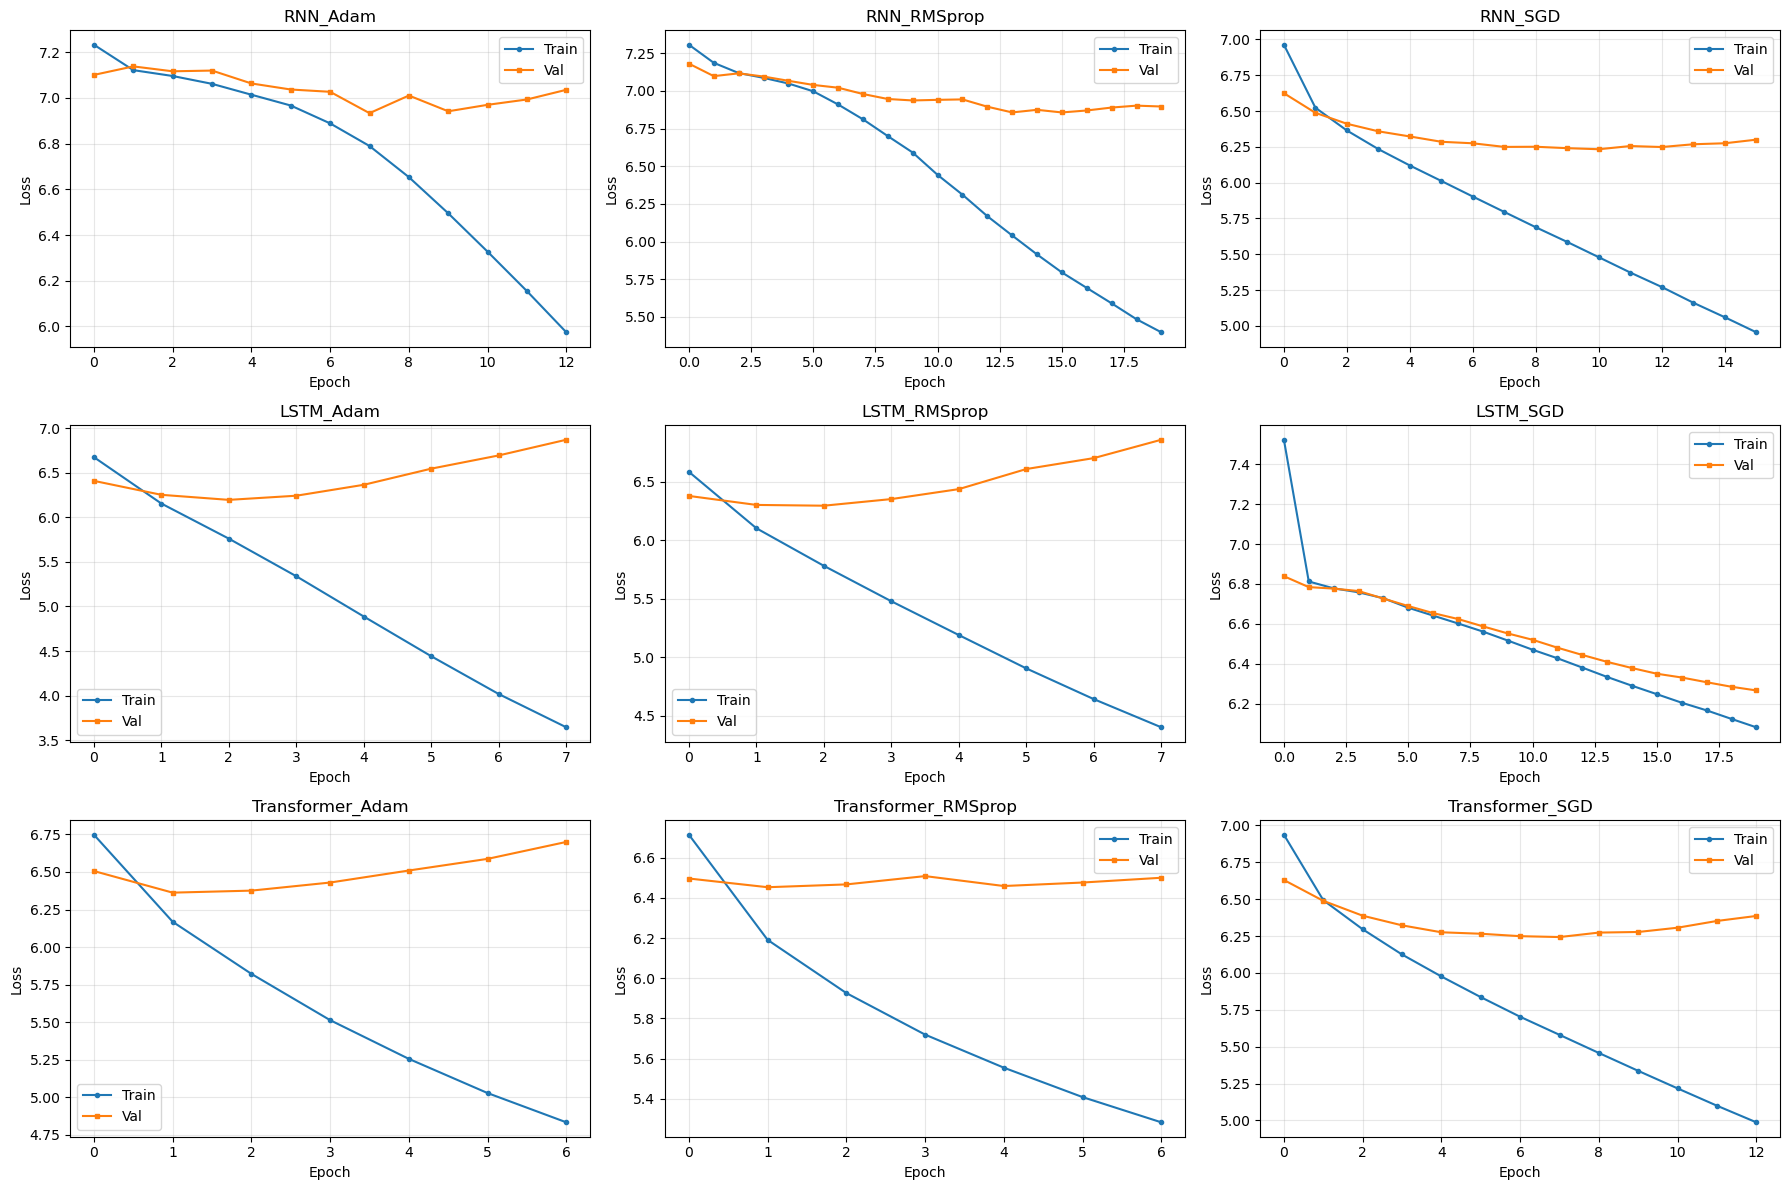

In [56]:
# ============================================================================
# CELL 15: Plot training & validation loss curves
# ============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, hist) in enumerate(all_histories.items()):
    ax = axes[i]
    ax.plot(hist["train_loss"], label="Train", marker="o", markersize=3)
    ax.plot(hist["val_loss"], label="Val", marker="s", markersize=3)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


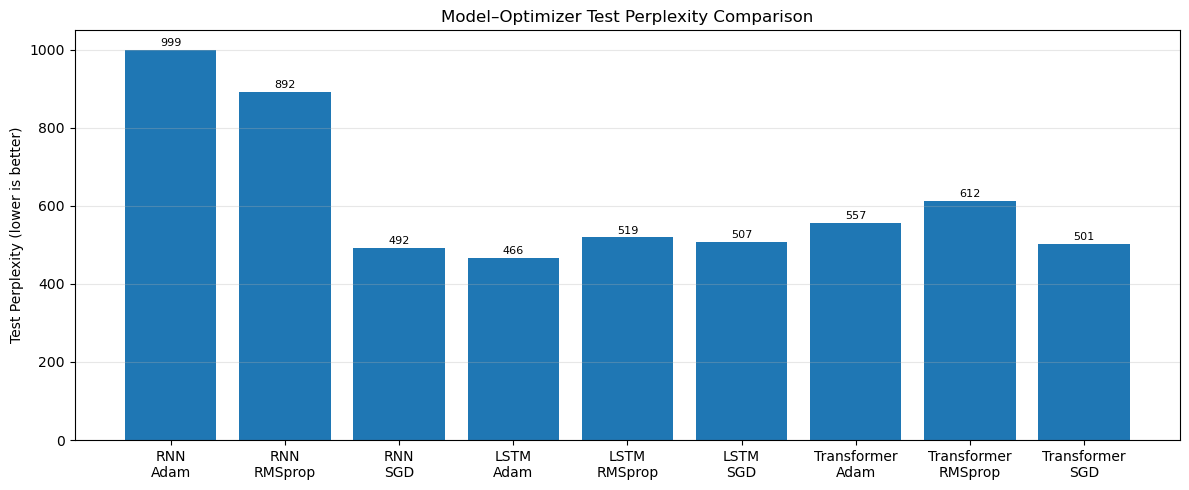

In [58]:
# ============================================================================
# CELL 16: Test perplexity comparison bar chart
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(results_df))
plt.figure(figsize=(12, 5))

plt.bar(x, results_df["Test_Perplexity"])
plt.xticks(x, [f"{m}\n{o}" for m, o in zip(results_df["Model"], results_df["Optimizer"])])
plt.ylabel("Test Perplexity (lower is better)")
plt.title("Model–Optimizer Test Perplexity Comparison")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(results_df["Test_Perplexity"]):
    plt.text(i, v + 10, f"{v:.0f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


In [60]:
# ============================================================================
# CELL 17: Load best model (lowest Test_Perplexity)
# ============================================================================

best_row = results_df.loc[results_df["Test_Perplexity"].idxmin()]
best_model_name = best_row["Model"]
best_opt_name   = best_row["Optimizer"]

print("Best combo:")
print(best_row)

# Instantiate the right class
if best_model_name == "LSTM":
    best_model = LSTMModel(vocab_size)
elif best_model_name == "RNN":
    best_model = SimpleRNN(vocab_size)
else:
    best_model = TransformerModel(vocab_size)

ckpt_path = f"models/{best_model_name}_{best_opt_name}_best.pth"
best_model.load_state_dict(torch.load(ckpt_path, map_location=device))
best_model.to(device)
best_model.eval()


Best combo:
Model                         LSTM
Optimizer                     Adam
Best_Val_Perplexity      490.36711
Test_Loss                 6.144085
Test_Accuracy             0.111725
Test_Perplexity          465.95316
Training_Time_Minutes      1.86447
Name: 3, dtype: object


LSTMModel(
  (embedding): Embedding(10000, 256, padding_idx=0)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=10000, bias=True)
)

In [62]:
# ============================================================================
# CELL 18: Text generation function
# ============================================================================

import torch.nn.functional as F

SEQUENCE_LENGTH = X.shape[1]  # should be 15

def generate_text(model, seed_text, word2idx, idx2word, max_length=30, temperature=1.0):
    model.eval()
    
    words = seed_text.split()
    token_list = [word2idx.get(w, word2idx["<UNK>"]) for w in words]
    generated = words.copy()
    
    with torch.no_grad():
        for _ in range(max_length):
            # pad/trim input to SEQUENCE_LENGTH
            if len(token_list) < SEQUENCE_LENGTH:
                input_seq = [0] * (SEQUENCE_LENGTH - len(token_list)) + token_list
            else:
                input_seq = token_list[-SEQUENCE_LENGTH:]
            
            input_tensor = torch.LongTensor([input_seq]).to(device)
            
            if isinstance(model, (SimpleRNN, LSTMModel)):
                logits, _ = model(input_tensor)
            else:
                logits = model(input_tensor)
            
            logits = logits / temperature
            probs = F.softmax(logits, dim=-1).squeeze(0)  # (vocab_size,)
            
            next_id = torch.multinomial(probs, 1).item()
            if next_id == 0:      # PAD → stop
                break
            
            next_word = idx2word.get(next_id, "<UNK>")
            generated.append(next_word)
            token_list.append(next_id)
    
    return " ".join(generated)

print("generate_text() ready.")


generate_text() ready.


In [64]:
# ============================================================================
# CELL 19: Generate sample Urdu poetry with best model
# ============================================================================

test_seeds = ["محبت", "دل", "شام", "یاد", "خوشی"]
temperatures = [0.7, 1.0, 1.3]

for seed in test_seeds:
    print(f"\n===== Seed: {seed} =====")
    for t in temperatures:
        out = generate_text(best_model, seed, word2idx, idx2word,
                            max_length=30, temperature=t)
        print(f"[T={t}] {out}")



===== Seed: محبت =====
[T=0.7] محبت میں ہوں غبار ترے بازو کی روداد ہے جو مقدر بھی رہا ہوں میں ہم کو نہیں کیا ہو کیا ہو کہ اب تم بھی ملے ہیں ہم کو خبر
[T=1.0] محبت ہم اتنے چور ہمارے تھے ہم تو بھی تھے تمہیں نہیں ہے یہ بھی ڈر نہیں رہا نہیں ہوں میں رکھو میں نہاں تو ہے الیاس نہیں دیکھا دیتا ہے
[T=1.3] محبت بھی نیم مند عرض کشتہ نہ ہوا تھا شب ناصح کیسی پھیریں کیے کرو اتنا کدے میں ہے ساحل سے تو آہ پہنچا نشہ ہے کہ خشت گئی ہنگامۂ پر

===== Seed: دل =====
[T=0.7] دل کی جو بات زیادہ ہوتا ہے سر برسوں کا اکیلا تھا کہ جس کو جانے میں نے دیکھا تھا خوشبو کے لیے اپنا اب آ کر نہیں سکتا والا ہے
[T=1.0] دل میں آیا بچہ سے وہ قبلہ سامنے ہی تھا شاید گردن کا پا مصحفیؔ ہوتا ہے نہ مجھے دے اس قدر معاملہ نہیں سکتا محسنؔ میں آنے کی بے وفا
[T=1.3] دل کی افلاطوں فروش چاہیئے نشاط دار نہاں ہوا گل رہتا ہے مجھے ہیں برہنہ یاد اے پہنچے شہر یہ حسرت بن جائیں دیے بدن دیوار تاب ساتھ چلو تھے سرکار

===== Seed: شام =====
[T=0.7] شام کو ہم سے شاید کہ بوسہ کے باقی نہیں ہوں میں ہوں کے ساتھ ساتھ چاند کو کیا کیجے ہائے ہو جائیں گے ہم 

In [66]:
# ============================================================================
# CELL 20: Per-model summary (aggregate over optimizers)
# ============================================================================

model_summary = (
    results_df
    .groupby("Model")
    .agg(
        Best_Test_Perplexity=("Test_Perplexity", "min"),
        Best_Test_Accuracy=("Test_Accuracy", "max"),
        Fastest_Training_Time_Min=("Training_Time_Minutes", "min"),
        Avg_Test_Perplexity=("Test_Perplexity", "mean"),
        Avg_Training_Time_Min=("Training_Time_Minutes", "mean"),
    )
    .reset_index()
    .sort_values("Best_Test_Perplexity")
)

print("Per-model summary:")
display(model_summary)


Per-model summary:


,Model,Best_Test_Perplexity,Best_Test_Accuracy,Fastest_Training_Time_Min,Avg_Test_Perplexity,Avg_Training_Time_Min
0,LSTM,465.953160,0.111725,1.684396,497.409409,2.439065
1,RNN,492.409188,0.098186,2.443389,794.484862,2.767960
2,Transformer,501.284924,0.097792,1.455449,556.619694,1.853106


In [68]:
# ============================================================================
# CELL 21: Per-optimizer summary (aggregate over models)
# ============================================================================

optimizer_summary = (
    results_df
    .groupby("Optimizer")
    .agg(
        Best_Test_Perplexity=("Test_Perplexity", "min"),
        Avg_Test_Perplexity=("Test_Perplexity", "mean"),
        Avg_Test_Accuracy=("Test_Accuracy", "mean"),
        Avg_Training_Time_Min=("Training_Time_Minutes", "mean"),
    )
    .reset_index()
    .sort_values("Best_Test_Perplexity")
)

print("Per-optimizer summary:")
display(optimizer_summary)


Per-optimizer summary:


,Optimizer,Best_Test_Perplexity,Avg_Test_Perplexity,Avg_Test_Accuracy,Avg_Training_Time_Min
0,Adam,465.953160,674.024346,0.088766,1.952819
2,SGD,492.409188,500.390658,0.096937,2.922712
1,RMSprop,518.797207,674.098962,0.098931,2.184600


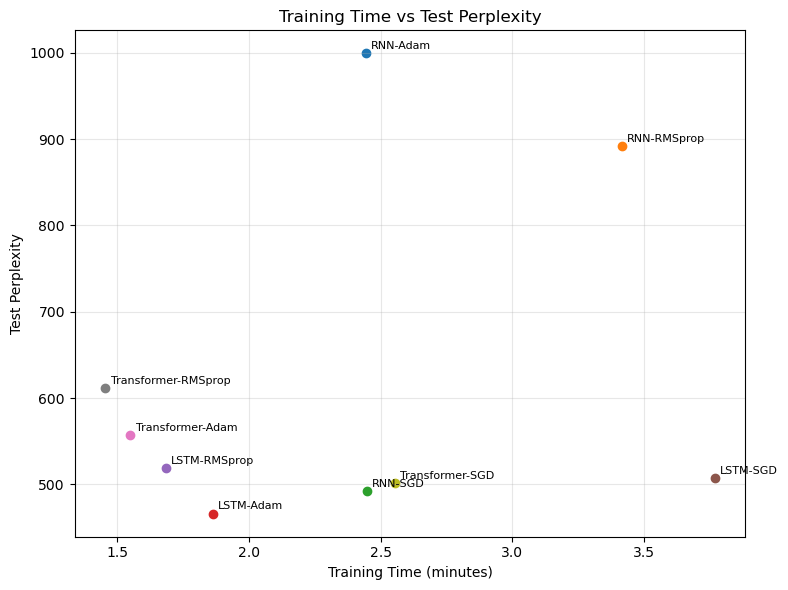

In [70]:
# ============================================================================
# CELL 22: Training time vs performance
# ============================================================================

plt.figure(figsize=(8, 6))

for i, row in results_df.iterrows():
    x = row["Training_Time_Minutes"]
    y = row["Test_Perplexity"]
    label = f"{row['Model']}-{row['Optimizer']}"
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 5, label, fontsize=8)

plt.xlabel("Training Time (minutes)")
plt.ylabel("Test Perplexity")
plt.title("Training Time vs Test Perplexity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
# ============================================================================
# CELL 23: Save sample generations from best model
# ============================================================================

os.makedirs("output", exist_ok=True)
gen_path = "output/sample_generations_lstm_adam.txt"

with open(gen_path, "w", encoding="utf-8") as f:
    f.write("Best combo: LSTM + Adam\n")
    f.write(str(best_row) + "\n\n")
    f.write("Sample generations:\n\n")

    test_seeds = ["محبت", "دل", "شام", "یاد", "خوشی"]
    temperatures = [0.7, 1.0, 1.3]

    for seed in test_seeds:
        f.write(f"===== Seed: {seed} =====\n")
        for t in temperatures:
            out = generate_text(best_model, seed, word2idx, idx2word,
                                max_length=30, temperature=t)
            f.write(f"[T={t}] {out}\n")
        f.write("\n")

print("Saved sample generations to:", gen_path)


Saved sample generations to: output/sample_generations_lstm_adam.txt


In [ ]:
## Conclusion

The model is able to learn patterns from Urdu poetry and generate new text sequences.
Sequence models demonstrate strong capability in capturing linguistic structure and stylistic patterns in natural language generation tasks.